In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

# Create extraction folders
os.makedirs('/content/dataset/train', exist_ok=True)
os.makedirs('/content/dataset/test', exist_ok=True)
os.makedirs('/content/dataset/valid', exist_ok=True)

# ZIP paths
train_zip = "/content/drive/MyDrive/brain_tumor_dataset/train-20260526T154843Z-3-001.zip"
test_zip  = "/content/drive/MyDrive/brain_tumor_dataset/test-20260526T154840Z-3-001.zip"
valid_zip = "/content/drive/MyDrive/brain_tumor_dataset/valid-20260526T154848Z-3-001.zip"

# Extract TRAIN
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/train')

# Extract TEST
with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/test')

# Extract VALID
with zipfile.ZipFile(valid_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/valid')

print("All datasets extracted successfully!")

All datasets extracted successfully!


In [4]:
import os

print(os.listdir('/content/dataset'))

['valid', 'train', 'test']


In [5]:
print(os.listdir('/content/dataset/test'))

['test']


In [6]:
print(os.listdir('/content/dataset/train/train'))

['meningioma', '_classes.csv', 'no_tumor', 'pituitary', 'glioma']


In [7]:
print(os.listdir('/content/dataset/valid/valid'))

['meningioma', '_classes.csv', 'no_tumor', 'pituitary', 'glioma']


In [8]:
print(os.listdir('/content/dataset/test/test'))

['meningioma', '_classes.csv', 'no_tumor', 'pituitary', 'glioma']


In [9]:
train_path = '/content/dataset/train/train'
valid_path = '/content/dataset/valid/valid'
test_path = '/content/dataset/test/test'

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [11]:
# STEP 2 — Define Image Size
IMG_SIZE = 224
BATCH_SIZE = 32

In [12]:
# STEP 3 — Create Data Generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
#STEP 4 — Load Dataset
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [14]:
# STEP 5 — Check Class Labels
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


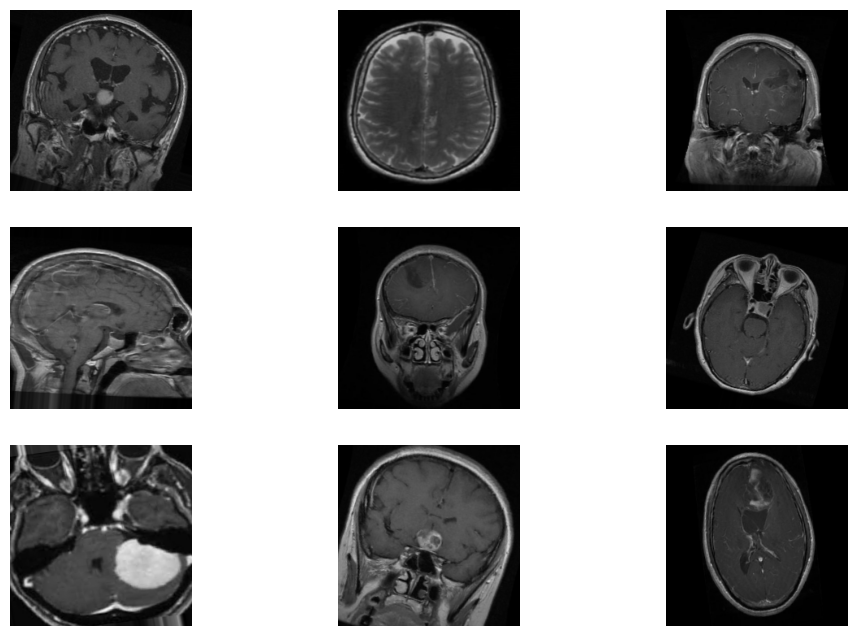

In [15]:
# STEP 6 — Display Sample Images
images, labels = next(train_data)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [16]:
# STEP 7 — Build CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
#STEP 8 — Build CNN Model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
# STEP 9 — View Model Summary
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# STEP 10 — Create Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "custom_cnn_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [20]:
# STEP 11 — TRAIN MODEL (MAIN PART)
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.4784 - loss: 12.5313

53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 681ms/step - accuracy: 0.5174 - loss: 6.8289 - val_accuracy: 0.3964 - val_loss: 34.8350
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 493ms/step - accuracy: 0.5156 - loss: 1.3461 - val_accuracy: 0.2351 - val_loss: 29.3732
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 461ms/step - accuracy: 0.4124 - loss: 1.3246 - val_accuracy: 0.2390 - val_loss: 15.4096
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.4852 - loss: 1.1722

53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 526ms/step - accuracy: 0.4914 - loss: 1.1822 - val_accuracy: 0.4562 - val_loss: 6.2661
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.5131 - loss: 1.1299

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 508ms/step - accuracy: 0.4684 - loss: 1.1875 - val_accuracy: 0.4701 - val_loss: 1.2842
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.4463 - loss: 1.1748

53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 503ms/step - accuracy: 0.4555 - loss: 1.1579 - val_accuracy: 0.5378 - val_loss: 1.2971
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 498ms/step - accuracy: 0.5357 - loss: 1.2251 - val_accuracy: 0.5319 - val_loss: 1.9144
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.4533 - loss: 1.3573

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step - accuracy: 0.4726 - loss: 1.2843 - val_accuracy: 0.6056 - val_loss: 0.9582
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 467ms/step - accuracy: 0.4767 - loss: 1.1104 - val_accuracy: 0.4880 - val_loss: 1.0470
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 482ms/step - accuracy: 0.5198 - loss: 1.3256 - val_accuracy: 0.5717 - val_loss: 5.2545
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.5380 - loss: 1.2346

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 505ms/step - accuracy: 0.5339 - loss: 1.1928 - val_accuracy: 0.6135 - val_loss: 0.9023
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4933 - loss: 1.1415

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 512ms/step - accuracy: 0.4891 - loss: 1.1517 - val_accuracy: 0.6534 - val_loss: 0.8382
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.5162 - loss: 1.0985

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 505ms/step - accuracy: 0.5162 - loss: 1.0903 - val_accuracy: 0.6693 - val_loss: 0.8058
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 482ms/step - accuracy: 0.5351 - loss: 1.1141 - val_accuracy: 0.5996 - val_loss: 0.9173
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 463ms/step - accuracy: 0.5552 - loss: 1.0756 - val_accuracy: 0.6394 - val_loss: 0.8935
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.5527 - loss: 1.0704

53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step - accuracy: 0.5434 - loss: 1.0411 - val_accuracy: 0.7171 - val_loss: 0.8626
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 517ms/step - accuracy: 0.5392 - loss: 1.0404 - val_accuracy: 0.6135 - val_loss: 0.8547
Epoch 18/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 496ms/step - accuracy: 0.5605 - loss: 1.0841 - val_accuracy: 0.1972 - val_loss: 305.0202


In [23]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
# STEP 1 — Import MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [26]:
# STEP 2 — Load Pretrained Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
#STEP 3 — Freeze Base Layers
base_model.trainable = False

In [29]:
# STEP 4 — Add Custom Layers
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(4, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [30]:
# STEP 5 — Model Summary
mobilenet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# STEP 6 — Compile Model
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
# STEP 7 — Train MobileNetV2
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7015 - loss: 0.7469 - val_accuracy: 0.7550 - val_loss: 0.5875
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 490ms/step - accuracy: 0.8254 - loss: 0.4612 - val_accuracy: 0.7829 - val_loss: 0.5398
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 487ms/step - accuracy: 0.8549 - loss: 0.4096 - val_accuracy: 0.8307 - val_loss: 0.4511
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 482ms/step - accuracy: 0.8773 - loss: 0.3557 - val_accuracy: 0.8287 - val_loss: 0.4685
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.8773 - loss: 0.3285 - val_accuracy: 0.8606 - val_loss: 0.3710
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 489ms/step - accuracy: 0.8844 - loss: 0.3284 - val_accuracy: 0.8008 - val_loss: 0.5231
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 487ms/step - accuracy: 0.8932 - loss: 0.2758 - val_accuracy: 0.8108 - val_loss: 0.5209
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 489ms/step - accuracy: 0.8920 - loss: 0.2737 - val_accurac

In [33]:
# STEP 8 — Evaluate MobileNetV2
loss, accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8374 - loss: 0.4306
MobileNetV2 Test Accuracy: 0.8373983502388


In [34]:
# STEP 9 — Save Model
mobilenet_model.save(
    '/content/drive/MyDrive/mobilenet_brain_tumor_model.h5'
)

print("MobileNetV2 Model Saved!")

MobileNetV2 Model Saved!


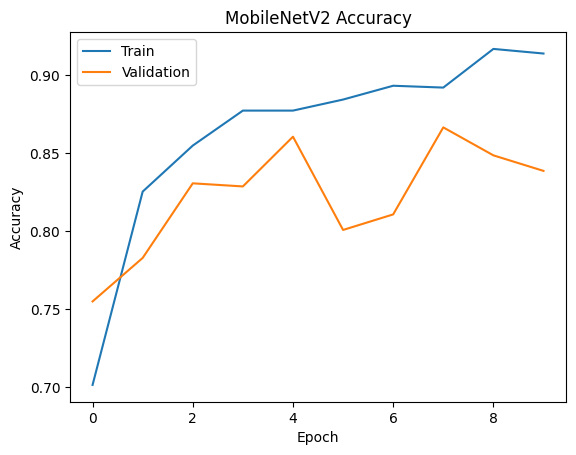

In [36]:
# STEP 1 — Accuracy Graph
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

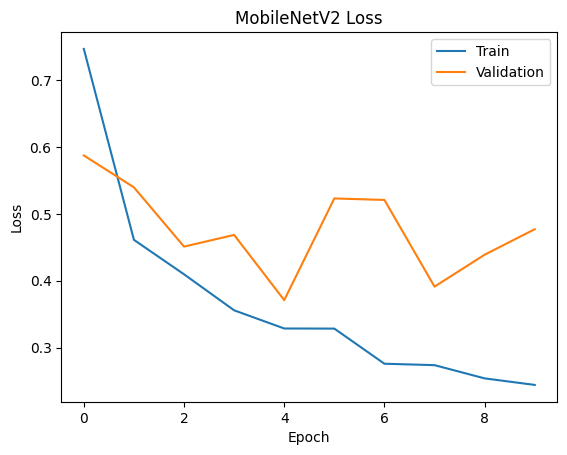

In [37]:
# STEP 2 — Loss Graph
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [38]:
# STEP 3 — Predictions
predictions = mobilenet_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 711ms/step


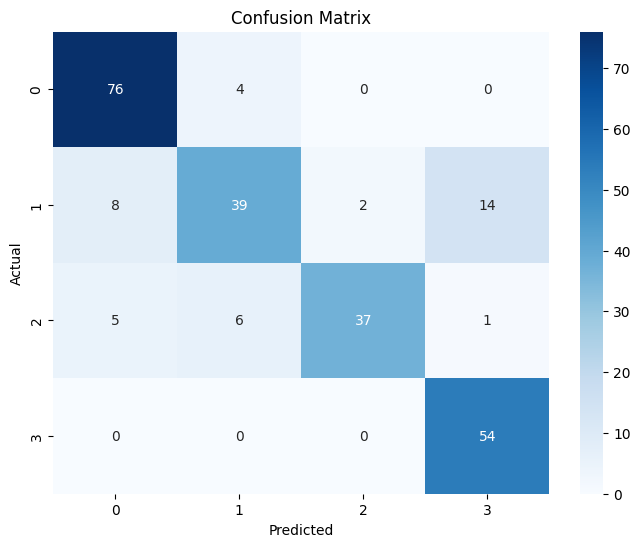

In [39]:
# STEP 4 — Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [40]:
# STEP 5 — Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=test_data.class_indices.keys()
))

              precision    recall  f1-score   support

      glioma       0.85      0.95      0.90        80
  meningioma       0.80      0.62      0.70        63
    no_tumor       0.95      0.76      0.84        49
   pituitary       0.78      1.00      0.88        54

    accuracy                           0.84       246
   macro avg       0.85      0.83      0.83       246
weighted avg       0.84      0.84      0.83       246

